<div style="box-sizing:border-box;max-width:100%;margin:0 0 8px;padding:4px 0;color:inherit;line-height:1.35;"><img src="https://thetahat.ru/images/logo_thetahat.png" alt="ThetaHat" style="display:block!important;width:52px!important;max-width:52px!important;height:auto!important;margin:0 0 9px 0!important;padding:0!important;"><div style="display:flex;align-items:center;justify-content:space-between;flex-wrap:wrap;gap:8px 12px;"><span style="min-width:0;color:inherit;font-size:12px;font-weight:700;letter-spacing:0.055em;text-transform:uppercase;"><a href="https://thetahat.ru/courses/ysda-group" style="color:inherit;text-decoration:none;">Школа анализа данных</a>&nbsp;·&nbsp;Машинное обучение</span></div></div>

<h2><span style="display:block;box-sizing:border-box;max-width:100%;padding:16px 22px 17px;border-radius:14px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 50%,#B316B8 100%);color:#FFFFFF;line-height:1.15;font-weight:500;">Домашнее задание 3. Логистическая регрессия.</span></h2>

<div style="box-sizing:border-box;max-width:100%;margin:18px 0 26px;padding:18px 20px;border:1px solid rgba(127, 127, 127, 0.28);border-left:4px solid #F13A3F;border-radius:12px;background:rgba(127, 127, 127, 0.07);color:inherit;">
  <div style="color:inherit;font-size:12px;font-weight:800;letter-spacing:0.08em;text-transform:uppercase;">Общие правила</div>
  <ul style="margin:10px 0 0;padding-left:22px;line-height:1.55;">
    <li>Выполненную работу <strong>в формате <code>ipynb</code></strong> нужно отправить в кабинете студента <a href="https://thetahat.ru/"><strong>на сайте ThetaHat</strong></a>. Инструкция по регистрации на сайте, записи на курс и сдаче домашек есть на странице курса в ЛМС. <strong>Работы, присланные иным способом, не принимаются.</strong> Дедлайны указаны в личном кабинете, они являются строгими.</li>
    <li>Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><strong>руководство по оформлению ДЗ</strong></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.</li>
    <li>Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><strong>правила использования ИИ-инструментов</strong></a> при решении домашнего задания.</li>
    <li>Выполнять задание необходимо полностью самостоятельно. <strong>При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф согласно правилам на странице курса.</strong></li>
    <li>Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/thetagrader"><img src="https://thetahat.ru/images/ai_eval_small.png" style="display:inline;vertical-align:middle;" alt="ThetaGrader"></a> <a href="https://thetahat.ru/thetagrader"><strong>ThetaGrader</strong></a>. Результаты проверки будут отправлены вам в течение 1-2 суток после дедлайна. После вы можете исправить ошибки или аргументировать свое мнение и отправить на проверку проверяющему. Подробнее на странице курса в ЛМС.</li>
    <li>Никакой код из данного задания при проверке запускаться не будет. <em>Если код не выполнен, недописан и т.д., то он не оценивается.</em></li>
  </ul>
  </br>
    
  <div style="color:inherit;font-size:12px;font-weight:800;letter-spacing:0.08em;text-transform:uppercase;">Правила заполнения ноутбука</div>
  <ul style="margin:8px 0 0;padding-left:22px;line-height:1.55;">
    <li>Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.</li>
    <li>Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены <code>&lt;...&gt;</code>.</li>
    <li>Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках. Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.</li>
    <li>В markdown-ячейках, содержащих описание задачи, находятся специальные отметки, которые <strong style="color:red;">запрещается модифицировать</strong>.</li>
    <li>Решение теоретических задач оформляйте в markdown-ячейках в формате $\LaTeX$. При решении можно использовать ИИ-инструменты для оформления написанного самостоятельно решения, например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.</li>
    <li>При нарушении данных правил работа может получить 0 баллов.</li>
  </ul>
</div>

## 🔵 <font color="blue">Часть L</font>

Дедлайн по части M во вторник 06.10 в 16:00. Дедлайн по этой части **в субботу 10.10 в 23:59**. Подробнее в описании курса в ЛМС.


**Баллы эту часть задания:**

* Задача 3 &mdash; 20 баллов;
* Задача 4 &mdash; 30 баллов;
* Задача 5 &mdash; 30 баллов;
* Задача 6 &mdash; 90 баллов.

In [133]:
import warnings

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as sps
import seaborn as sns
from sklearn import metrics
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_blobs
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler



from notebook_logreg_tools import (
    measure_time,
    save_model_and_get_size,
    plot_compare_model_performance,
    ModelBenchmark,
    visualize_data,
    plot_logreg_coefficients,
    plot_logit_linearity_check,
    plot_decision_boundary,
)


sns.set(style="whitegrid", palette="Set2")

In [3]:
# Bot check

# HW_ID: ysda_ml1_task_l3
# Система проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так система проверит, что ты ничего не перепутал, и отправляешь финальную версию,
# а не промежуточную. После отправки работы со статусом final до дедлайна все 
# еще можно вносить исправления и отправлять повторно.

# Никакие значения в этой ячейке не влияют на факт сдачи работы.

---

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 3-5**
1. https://p.ip.fi/XKni
    - Помощь в оформлении latex


---
### <span style="display:inline-block;padding:6px 13px;border-radius:999px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 55%,#B316B8 100%);color:#FFFFFF;font-size:16px;font-weight:700;line-height:1.2;">Задача 3</span>


Найдите оценку параметра $\theta$ методом максимального правдоподобия по выборке размера $n$ из указанных далее распределений.

Минимизируем
$$
L(\theta) = p(x_1,\theta)\cdots p(x_n,\theta).
$$

$$
\frac{d\ln L(\theta)}{d\theta}
=
\frac{d}{d\theta}\sum_{i=1}^{n}\ln p(x_i,\theta).
$$

### 1. $\mathrm{Exp}(\theta)$

$$
p(x_i,\theta) = \theta e^{-\theta x_i}.
$$

$$
\begin{aligned}
\ln L(\theta)
&= \ln\left(\theta^n e^{-\theta n\overline{X}}\right) \\
&= n\ln\theta - n\theta\overline{X}.
\end{aligned}
$$

$$
\frac{d\ln L(\theta)}{d\theta}
= \frac{n}{\theta} - n\overline{X}
= 0
\quad\Rightarrow\quad
\theta = \frac{1}{\overline{X}}.
$$

### 2. $\mathrm{Pois}(\theta)$

$$
p(x_i,\theta) = \frac{\theta^{x_i}e^{-\theta}}{x_i!}.
$$

$$
\begin{aligned}
\ln L(\theta)
&= \ln\left(
\frac{e^{-n\theta}\theta^{n\overline{X}}}
{\prod_{i=1}^{n}x_i!}
\right) \\
&= -n\theta + n\overline{X}\ln\theta
- \ln\left(\prod_{i=1}^{n}x_i!\right).
\end{aligned}
$$

$$
\frac{d\ln L(\theta)}{d\theta}
= -n + \frac{n\overline{X}}{\theta}
= 0
\quad\Rightarrow\quad
\theta = \overline{X}.
$$

---
### <span style="display:inline-block;padding:6px 13px;border-radius:999px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 55%,#B316B8 100%);color:#FFFFFF;font-size:16px;font-weight:700;line-height:1.2;">Задача 4</span>

*Не все в жизни ограничивается двумя классами, бывает и многоклассовый случай.*

**1.** Пусть $X_1,...,X_n$ &mdash; выборка независимых одинаково распределенных случайных величин из категориального распределения, то есть $\mathsf{P}_\theta(X_1 = j) = \theta_j$ для $j \in \{1, ..., k\}$, причем $\theta = (\theta_1, ..., \theta_k), \theta_j \geqslant 0$ и $\theta_1 + ... + \theta_k = 1$. Найдите оценку максимального правдоподобия параметра $\theta$. Является ли она несмещенной оценкой $\theta$?


<br/>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Кликни для показа подсказки</summary>

Посмотрите на пример с лекции для бернуллиевского распределения.

</details>

$$
p(x_i,\theta) = \theta_{x_i},
$$
где $x_i$ — индекс класса.

$$
L(\hat{\theta}) = \prod_i \hat{\theta}_{x_i}.
$$

$$
\ln L(\hat{\theta})
= \sum_i \ln\hat{\theta}_{x_i}
= \sum_i k_i\ln\hat{\theta}_i,
$$
где $k_i$ — число выпавших элементов класса $i$.

Воспользуемся методом множителей Лагранжа:

$$
\ln L(\hat{\theta})
= \sum_i k_i\ln\hat{\theta}_i
+ \lambda\left(1-\sum_i\hat{\theta}_i\right).
$$

$$
\nabla\bigl(\ln L(\hat{\theta})\bigr) = 0
\quad\Rightarrow\quad
\begin{cases}
\dfrac{k_1}{\hat{\theta}_1} - \lambda = 0, \\[6pt]
\vdots \\[6pt]
\dfrac{k_n}{\hat{\theta}_2} - \lambda = 0, \\[6pt]
\displaystyle\sum_i\hat{\theta}_i - 1 = 0.
\end{cases}
$$

$$
\sum_i k_i - \lambda\left(\sum_i\hat{\theta}_i\right) = 0
\quad\Rightarrow\quad
\lambda = n.
$$

$$
\hat{\theta}_i = \frac{k_i}{n}.
$$

Оценим несмещённость $\hat{\theta}$:

$$
\mathbb{E}[\hat{\theta}_j]
= \mathbb{E}\left[\frac{k_j}{n}\right],
$$
то есть математическое ожидание доли объектов, выпавших в классе $j$.

Эта доля в среднем равна исходному параметру модели $\theta_j$, поэтому

$$
\mathbb{E}[\hat{\theta}_j] = \theta_j.
$$

Следовательно, оценка $\hat{\theta}_j$ несмещённая.

**2.** Рассмотрим модель логистической регрессии для случая многоклассовой классификации. Пусть метка класса принимает значения в $K$-элементном множестве $\mathscr{Y} = \{1, ..., K\}$. Параметры модели $\theta$ являются матрицей размерности $K \times d$, где $d$ &mdash; количество признаков. 

Введем soft-max функцию: 

$$
\sigma(z) = \left( \frac{e^{z_1}}{\sum_{j=1}^K e^{z_j}}, \dots, \frac{e^{z_K}}{\sum_{j=1}^K e^{z_j}} \right).
$$

Из определения ясно, что $\sum\limits_{j=1}^k \sigma_j(z) = 1$. Название функции связано с тем, что самая большая компонента вектора $z$ будет близка к $1$, а все остальные будут малы, но не равны нулю. Таким образом, происходит сглаженное взятие `argmax`.

По аналогии с обычной логистической регрессией рассмотрим выборку объектов $x_1, ...,  x_n$, где $x_i = (x_{i1}, \dots, x_{id})^T \in \mathscr{X}$, и выборку таргетов $Y_1, ...,  Y_n \in \mathscr{Y}$. Модель логистической регрессии в многоклассовом случае предполагает, что $\mathsf{P}_{\theta}(Y_{i} = k) = \sigma_k(\theta x)$.

Выполните следующие действия.

Определите множество моделей $\mathcal{M}$, соответствующее логистической регрессии.

Два класса:

$$
M = \left\{
x \mapsto \operatorname{sigmoid}(\theta^\top x)
\;\middle|\;
\theta \in \mathbb{R}^d
\right\}.
$$

$K$ классов:

$$
M = \left\{
x \mapsto \sigma(\theta x)
\;\middle|\;
\theta \in \mathbb{R}^{K \times d}
\right\}.
$$

Запишите функцию правдоподобия для такой модели.

$$
L(\theta)
= \prod_i P_\theta(Y_i = k)
= \prod_i \bigl(\sigma(\theta x_i)\bigr)_{Y_i}.
$$

Выпишите формулы GD и SGD для максимизации этой функции правдоподобия. В формулу нужно упростить подобно тому, как было показано на занятии.

Обозначим

$$
\theta =
\begin{pmatrix}
\theta_1^\top \\
\vdots \\
\theta_K^\top
\end{pmatrix}.
$$

$$
p_{ik}
= P_\theta(y_i = k \mid x_i)
= \frac{\exp(\theta_k^\top x_i)}
{\displaystyle\sum_{j=1}^{K}\exp(\theta_j^\top x_i)}.
$$

Тогда

$$
L(\theta) = \prod_i \sigma(\theta x_i)_{y_i},
$$

$$
\ell(\theta)
= \ln L(\theta)
= \sum_i \ln \sigma(\theta x_i)_{y_i}.
$$

$$
\ln \sigma(\theta x_i)_{y_i}
= (\theta x_i)_{y_i}
- \ln\left(\sum_{j=1}^{K}\exp\bigl((\theta x_i)_j\bigr)\right).
$$

$$
(\theta x_i)_{y_i}
=
\left(
\begin{pmatrix}
\theta_1^\top \\
\vdots \\
\theta_K^\top
\end{pmatrix}
x_i
\right)_{y_i}
= \theta_{y_i}^\top x_i.
$$

Следовательно,

$$
\underbrace{\ln \sigma(\theta x_i)_{y_i}}_{\ell_i(\theta)}
=
\theta_{y_i}^\top x_i
- \ln\left(\sum_{j=1}^{K}\exp\bigl((\theta x_i)_j\bigr)\right),
$$

$$
\ell(\theta) = \sum_i \ell_i(\theta).
$$

$$
\begin{aligned}
\frac{\partial \ell_i(\theta)}{\partial \theta_{kr}}
&=
\mathbf{1}\{y_i = k\}\,x_{ir}
-
\frac{\exp(\theta_k^\top x_i)\,x_{ir}}
{\displaystyle\sum_{j=1}^{K}\exp(\theta_j^\top x_i)}
\\
&=
\bigl(\mathbf{1}\{y_i = k\} - p_{ik}\bigr)x_{ir}.
\end{aligned}
$$

Тогда

$$
\theta^{(t+1)}
=
\theta^{(t)}
+
\alpha\frac{\nabla\ell(\theta)}{n}.
$$

$$
\theta_{kr}^{(t+1)}
=
\theta_{kr}^{(t)}
+
\frac{\alpha}{n}
\sum_i
\bigl(\mathbf{1}\{y_i = k\} - p_{ik}\bigr)x_{ir}.
$$

$$
\Rightarrow GD: \quad
\theta^{(t+1)}
=
\theta^{(t)}
+
\frac{\alpha}{n}
\sum_i
\bigl(\mathbf{1}_{y_i} - p_i\bigr)x_i^\top,
$$

где

$$
\begin{aligned}
p_i &= \sigma(\theta x_i), \\[6pt]
\mathbf{1}_{y_i}
&=
\begin{pmatrix}
\mathbf{1}\{y_i = 1\} \\
\vdots \\
\mathbf{1}\{y_i = K\}
\end{pmatrix}.
\end{aligned}
$$

Обозначим $I$ — случайную подвыборку $x_i$ на очередном шаге. Тогда

$$
\text{SGD:}\qquad
\theta^{(t+1)}
=
\theta^{(t)}
+
\frac{\alpha}{|I|}
\sum_{i\in I}
\bigl(\mathbf{1}_{y_i} - p_i\bigr)x_i^\top.
$$

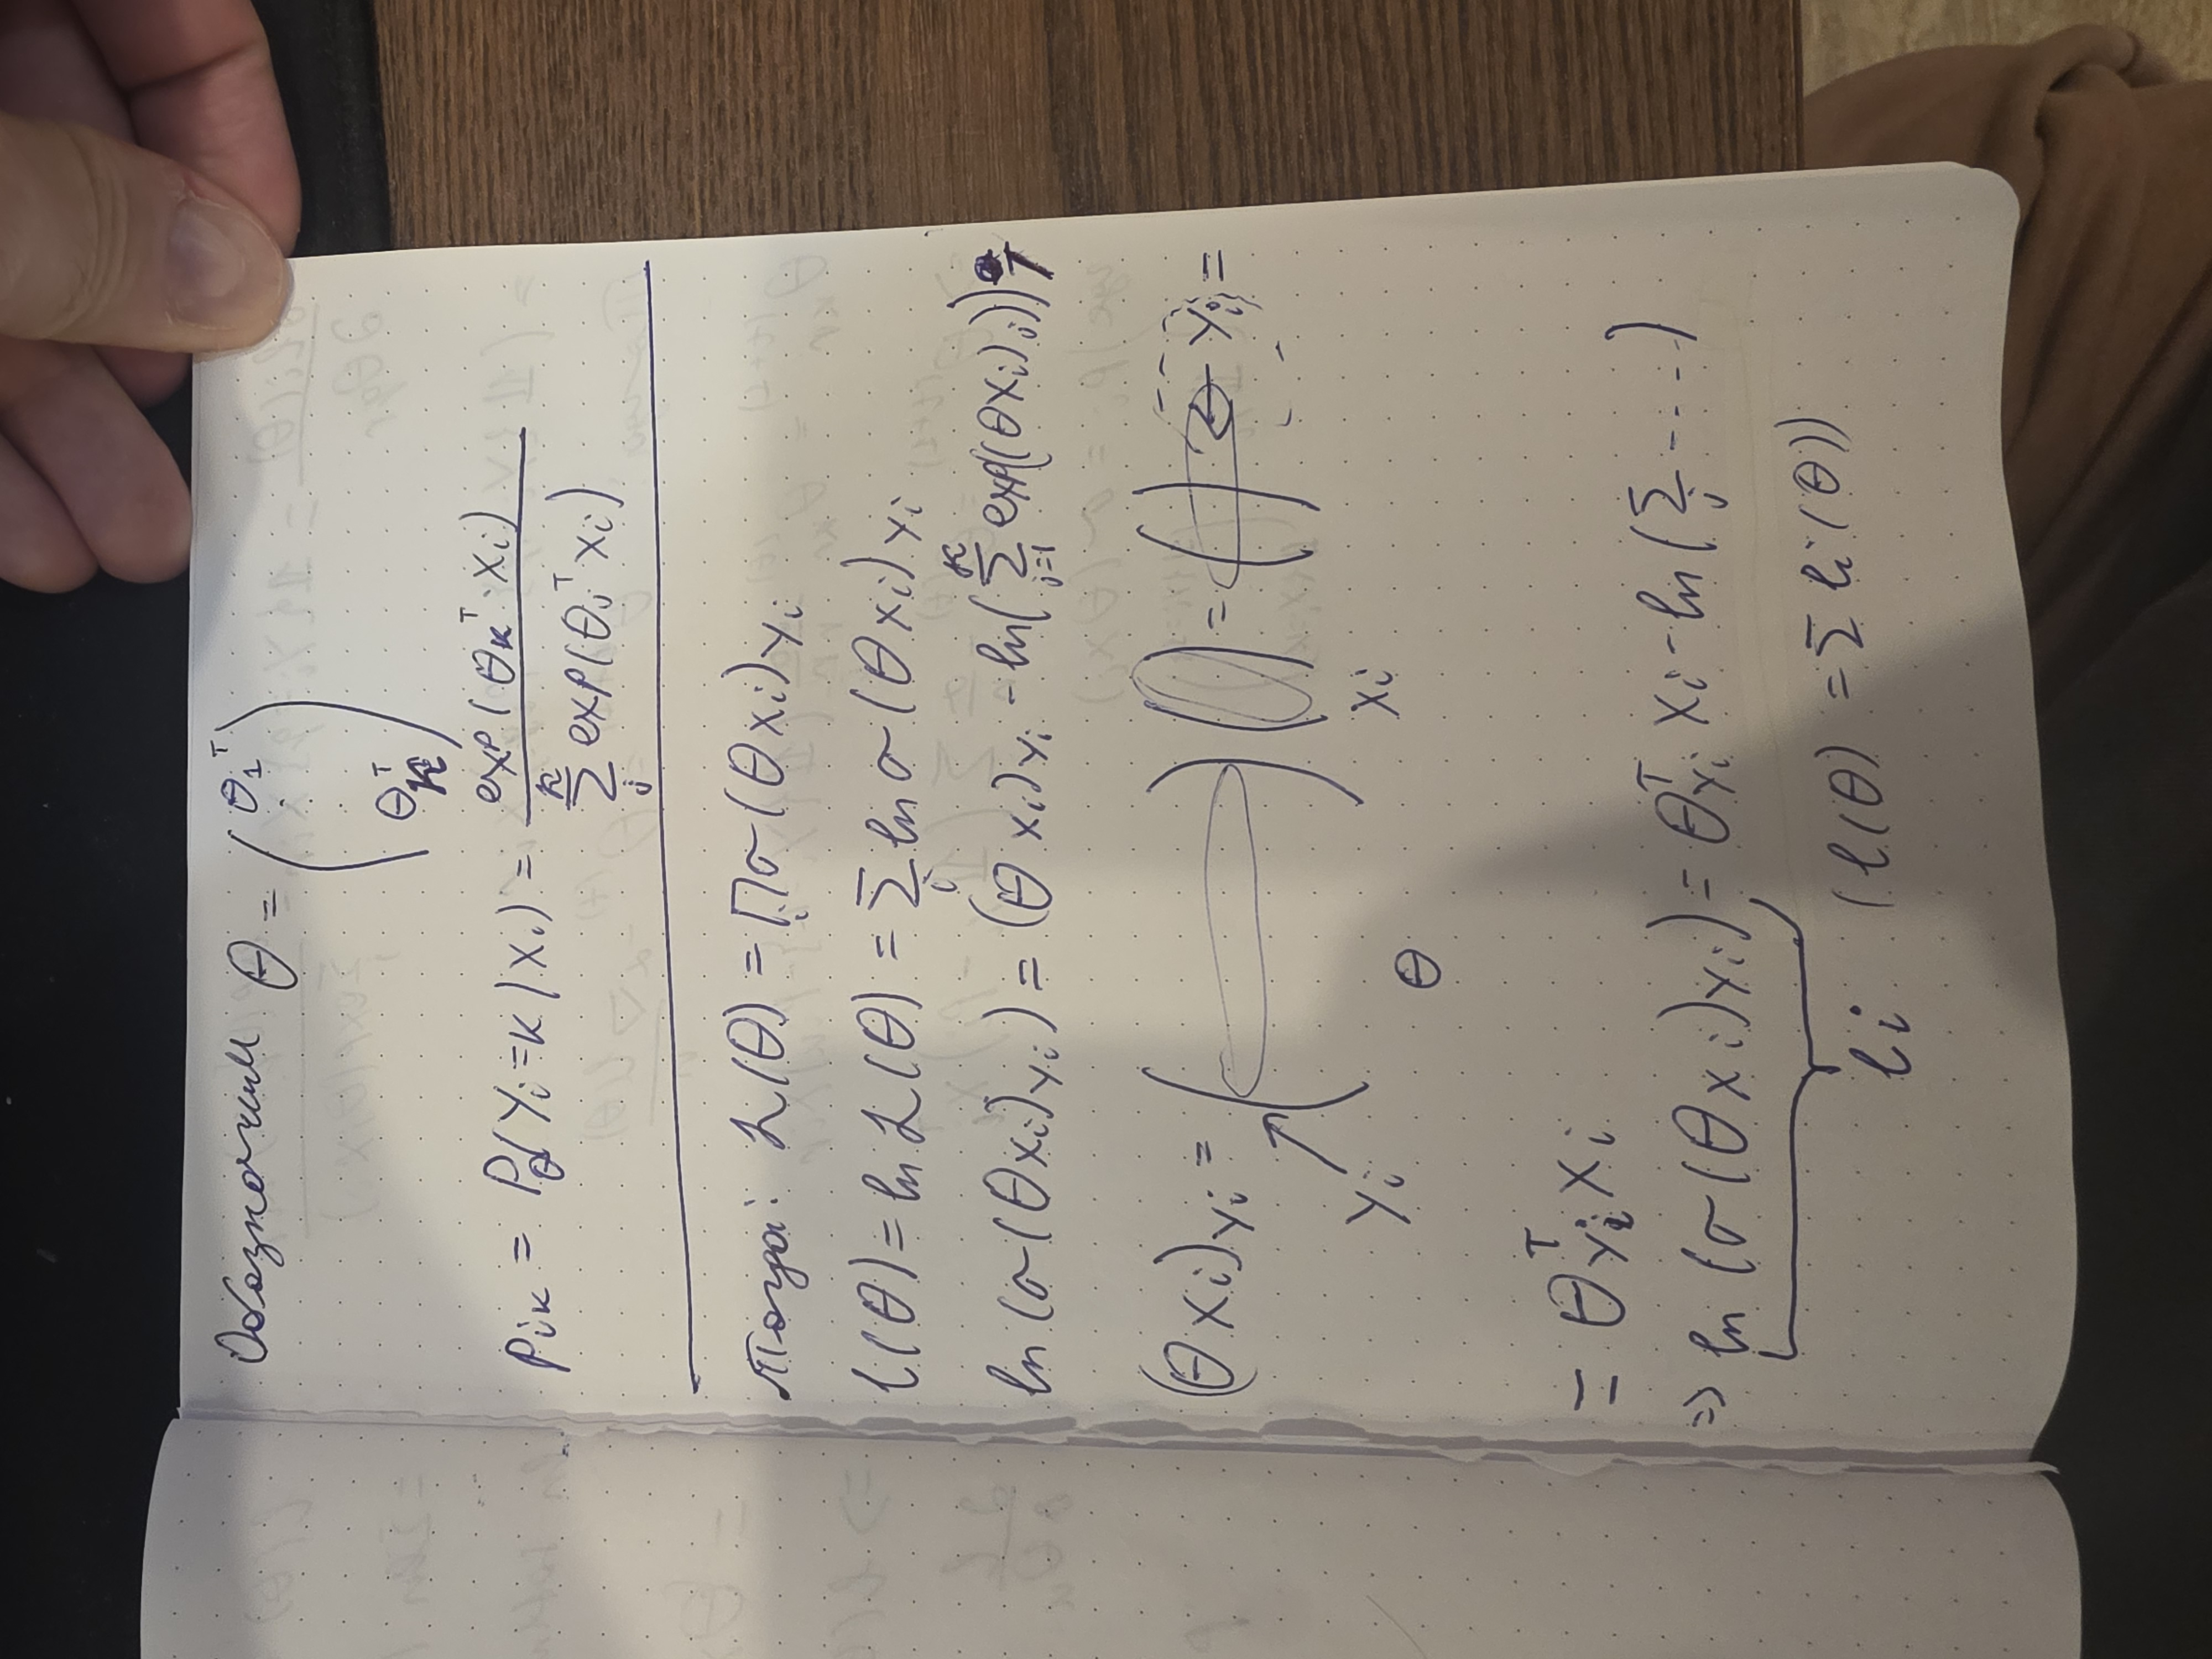 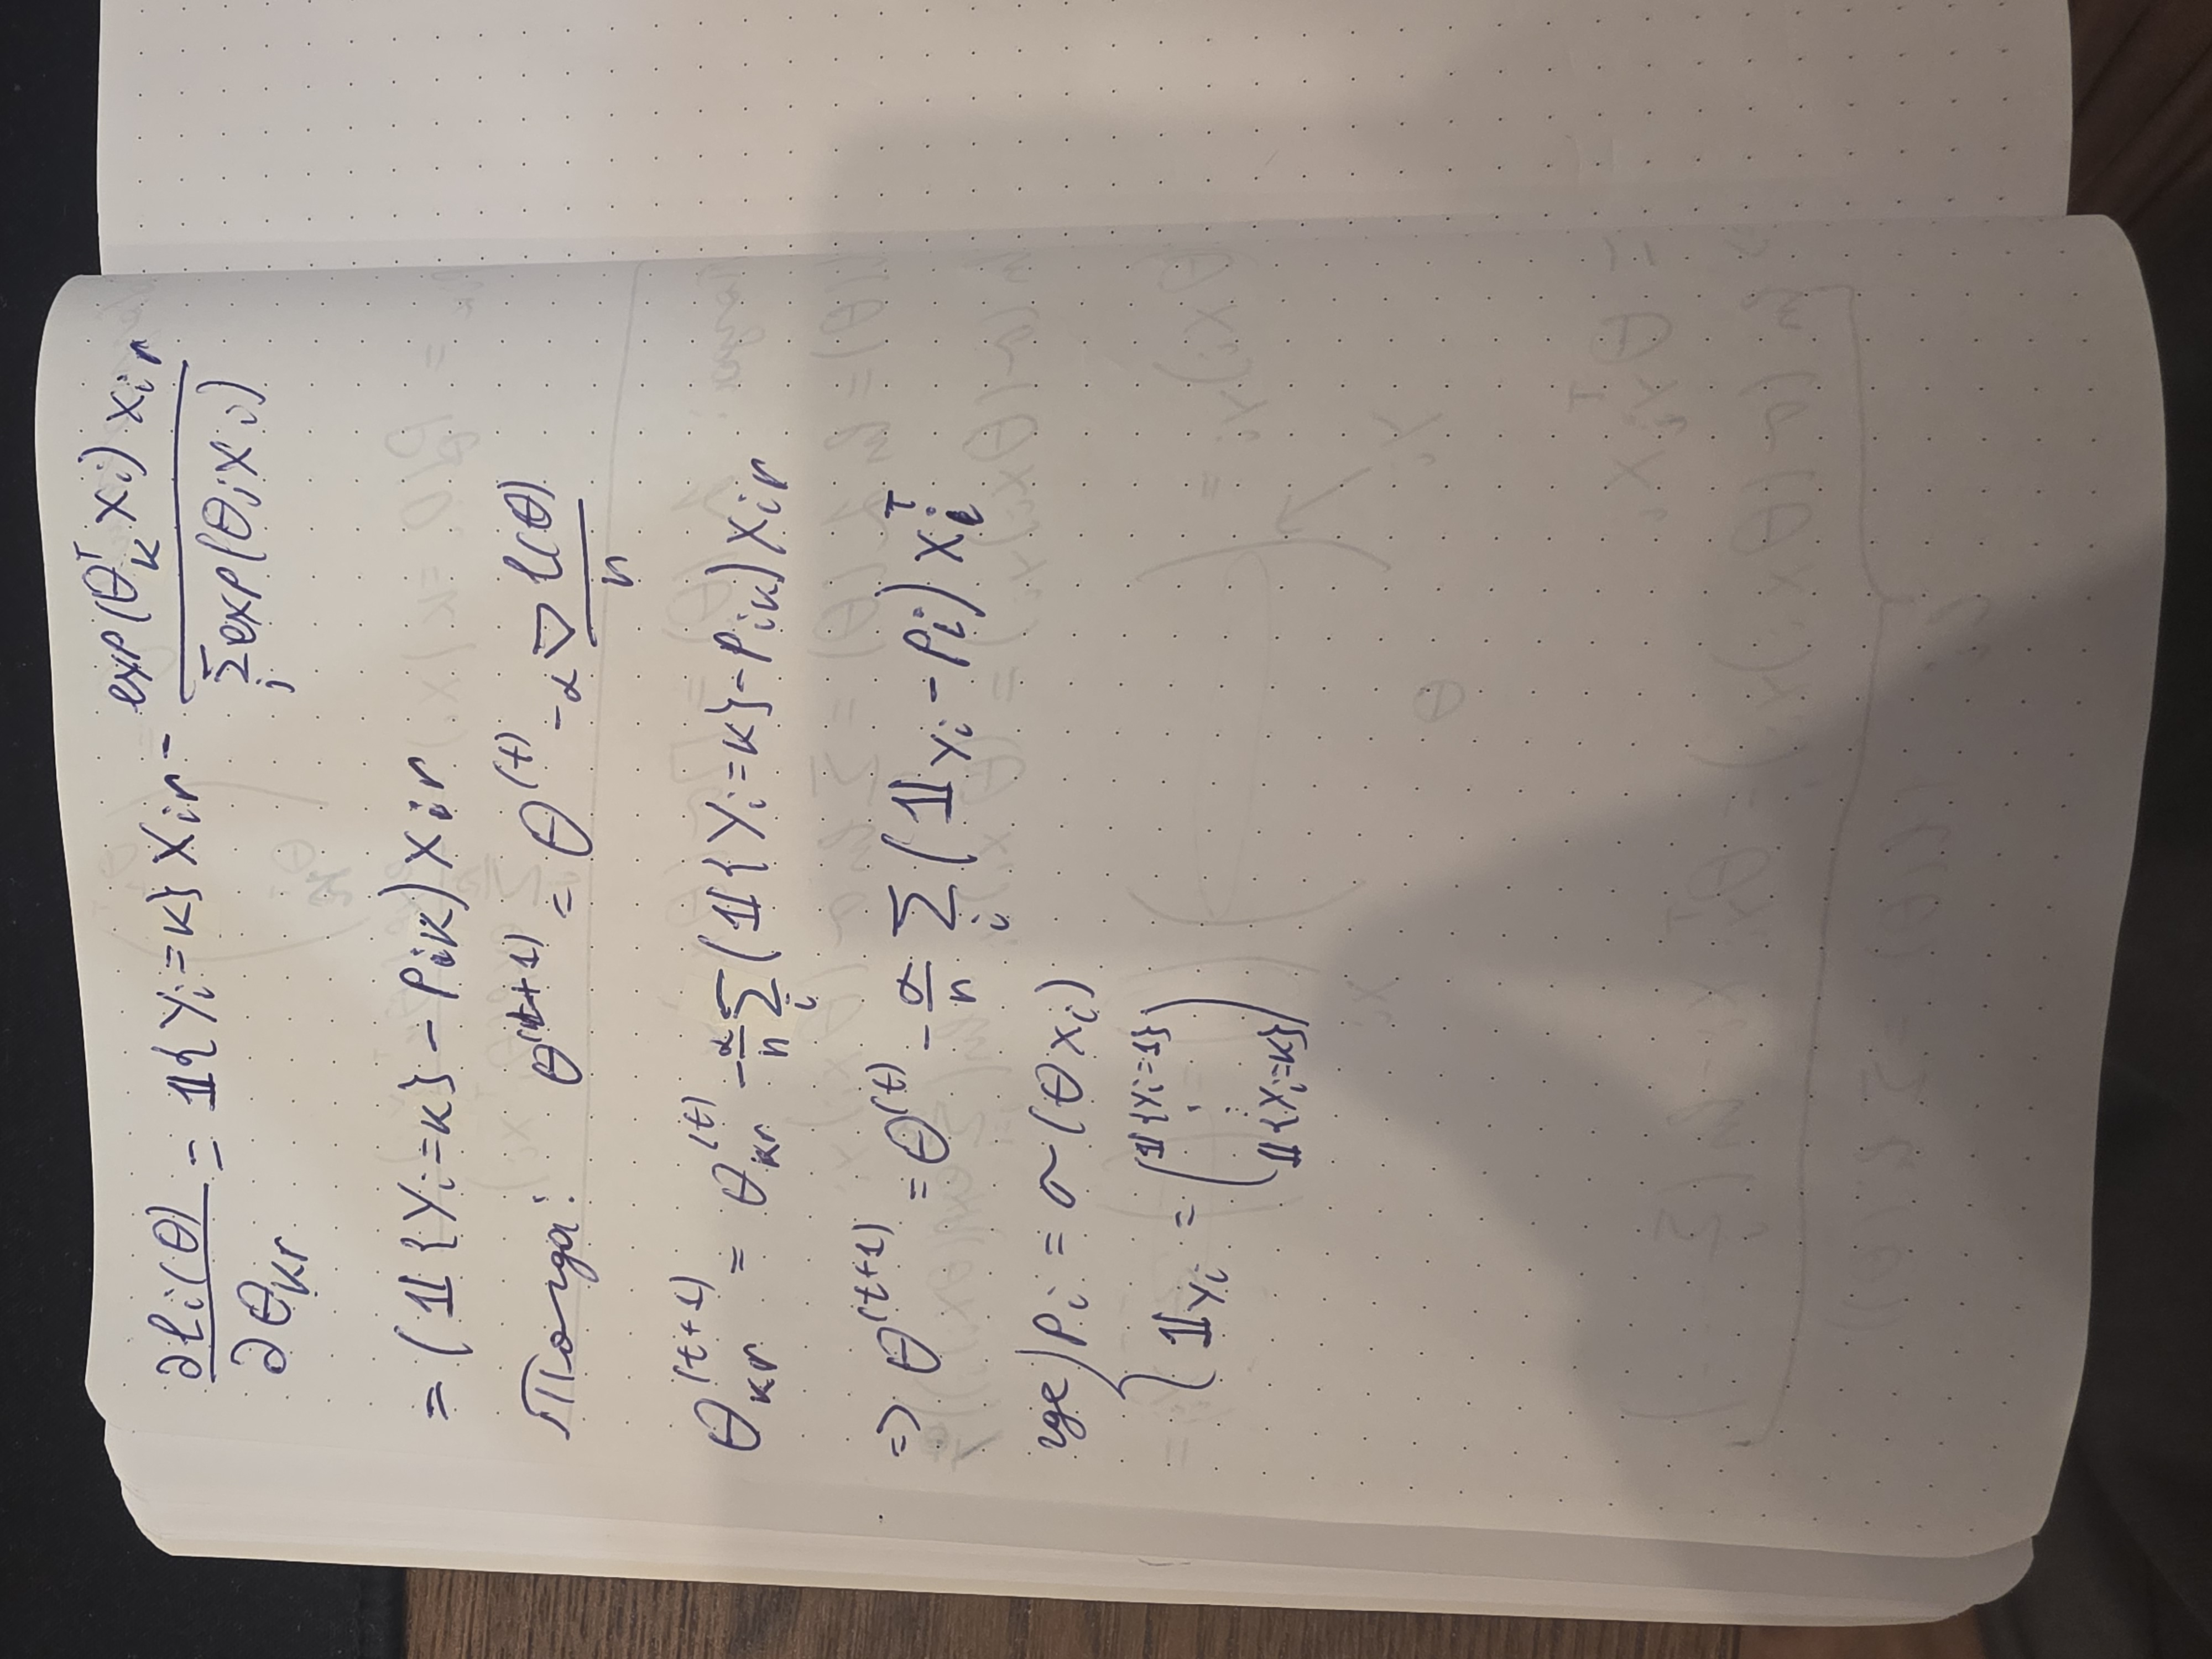

(В конце поправил знак потом)

*Логистическую регрессию для многоклассового случая можно применять и другими способами, подробнее в материале с занятия.*

---
### <span style="display:inline-block;padding:6px 13px;border-radius:999px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 55%,#B316B8 100%);color:#FFFFFF;font-size:16px;font-weight:700;line-height:1.2;">Задача 5</span>

*Устали писать формулы? Самое время что-то закодить!*

*Обрати внимание, что выполнение это задачи требуется для полноценного решения следующей. Тем не менее, если ты не хочешь кодить, можно сразу переходить к следующей задаче и выполнить то, что получится выполнить с помощью готовых инструментов. В таком случае можно получить частичные баллы за следующую задачу.*


**1.** Реализуйте логистическую регрессию для бинарной классификации для двух вариантов поиска оценки параметров:
* простой градиентный спуск;
* стохастический градиентный спуск с `batch_size` элементами на каждой итерации.

Останавливайте итерации при выполнении хотя бы одного из двух условий:
* количество итераций превзошло число `max_iter`;
* оптимизируемый функционал изменился за итерацию не более чем на `tol`.

Если указан параметр `save_history`, после выполнения каждой итерации с целью дальнейшего анализа в поле `self.history` сохраняйте 
* время, прошедшее с момента начала обучения
* значение оптимизируемого функционала:
    * полная кросс-энтропия для случая простого градиентного спуска
    * оценка кросс-энтропии для случая стохастического градиентного спуска, оценка должна быть произведена по тому же батчу объектов, который использовался для выполнения шага обучения.

*Замечания.*

1. Время измеряйте с помощью `from time import time`.

2. Иногда при подсчете сигмоиды и оптимизируемого функционала могут возникать вычислительные ошибки. Для их избежания существуют специальные трюки.
    * [How to Evaluate the Logistic Loss and not NaN trying](http://fa.bianp.net/blog/2019/evaluate_logistic/)
    * [Exp-normalize trick](https://timvieira.github.io/blog/post/2014/02/11/exp-normalize-trick/)<br>
3. Трюки не обязательно реализовывать самостоятельно, можете воспользоваться функциями для них из `numpy` или `scipy`:
    * [`numpy.logaddexp`](https://numpy.org/doc/stable/reference/generated/numpy.logaddexp.html);
    * [`scipy.special.logsumexp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.logsumexp.html).
4. Обратите внимание, что класс `MyLogisticRegression` &mdash; наследник класса `BaseEstimator`, это с легкостью позволит использовать наш класс в различных пайплайнах библиотеки `sklearn`.
4. Следите за качеством кода, комментируйте логические этапы кода. Несоблюдение этого требования может привести к потере баллов.


**При реализации класса запрещено пользоваться ИИ-инструментами.**


In [65]:
# При реализации класса запрещено пользоваться ИИ-инструментами.

from time import time
from scipy.special import logsumexp
from sklearn.base import BaseEstimator
from scipy.special import expit
from typing import Literal

class MyLogisticRegression(BaseEstimator):
    """Модель логистической регрессии.

    Параметры:
    method (Literal['gd', 'sgd']): Метод оптимизации ('gd' - градиентный спуск,
        'sgd' - стохастический градиентный спуск).
    learning_rate (float): Константа скорости обучения, на которую домножаем градиент при обучении
    tol (float): Допустимое изменение функционала между итерациями.
    max_iter (int): Максимальное число итераций.
    batch_size (int): Размер выборки для оценки градиента (используется только при 'sgd').
    fit_intercept (bool): Добавлять ли константу в признаки.
    save_history (bool): Сохранять ли историю обучения.
    """

    def __init__(
        self,
        method: Literal["gd", "sgd"] = "gd",
        learning_rate: float = 0.1,
        tol: float = 1e-3,
        max_iter: int = int(1e4),
        batch_size: int = 64,
        fit_intercept: bool = True,
        save_history: bool = True,
    ):
        """Создает модель и инициализирует параметры."""
        self.method = method
        self.learning_rate = learning_rate
        self.tol = tol
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.fit_intercept = fit_intercept
        self.save_history = save_history
        self.history = []  # Сюда сохраняйте историю обучения

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        """Вычисляет сигмоидную функцию."""
        return expit(z)

    def _add_intercept(self, X: np.ndarray) -> np.ndarray:
        """Добавляет свободный коэффициент к матрице признаков.

        Параметры: X (np.ndarray): Исходная матрица признаков.

        Возвращает: np.ndarray: Матрица X с добавленным свободным
        коэффициентом.
        """
        X_copy = np.ones((X.shape[0], X.shape[1] + 1), dtype=float)
        X_copy[:, :-1] = X
        return X_copy

    def fit(self, X: np.ndarray, Y: np.ndarray) -> "LogisticRegression":
        """Обучает модель логистической регрессии.

        Также, в случае self.save_history=True, добавляет в self.history
        текущее значение оптимизируемого функционала и затраченное время.

        Параметры:
        X (np.ndarray): Матрица признаков.
        Y (np.ndarray): Вектор истинных меток.

        Возвращает:
        LogisticRegression: Обученная модель.
        """
        if X.shape[0] != Y.shape[0]:
            raise ValueError("Количество строк в X и Y должно совпадать")

        if not np.isfinite(X).all(axis=None):
            raise ValueError("X содержит NaN или бесконечности")
        
        if not np.isfinite(Y).all(axis=None):
            raise ValueError("Y содержит NaN или бесконечности")

        if self.fit_intercept:
            X_copy = self._add_intercept(X)
        else:
            X_copy = X.copy()

        start = time()
    
        theta = np.zeros(X_copy.shape[1])
        for i in range(self.max_iter):
            if self.method.lower().strip() == "sgd":
                I = np.random.choice(X_copy.shape[0], size=self.batch_size, replace=False)
                X_I = X_copy[I]
                Y_I = Y.iloc[I]
            else:
                I = np.arange(len(Y))
                X_I = X_copy
                Y_I = Y


            z = X_I @ theta

            y_pred = self._sigmoid(z)
            residuals = Y_I - y_pred
            adjusted = X_I.T @ residuals
            diff = self.learning_rate * adjusted / len(Y_I)
            theta += diff

            if self.save_history:
                now = time()
                signed_z = np.where(Y_I == 1, -z, z)
                loss = np.logaddexp(0.0, signed_z).mean()
                self.history.append((now - start, loss))

            if np.linalg.norm(diff) < self.tol * np.linalg.norm(theta):
                break
            
            
        self.intercept_ = 0
        if self.fit_intercept:
            self.intercept_ = theta[-1]
            theta = theta[:-1]
            
        self.coef_ = theta  # Коэффициенты модели
        self.n_iter_ = i + 1 # Число итераций

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Возвращает вероятности классов 0 и 1.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Матрица вероятностей классов (n_samples, 2).
        """

        if X.shape[1] != self.coef_.shape[0]:
            raise ValueError("Число признаков в X не соответствует числу коэффициентов модели")
            
        if self.fit_intercept:
            X_copy = self._add_intercept(X)
            theta = np.append(self.coef_, self.intercept_)
        else:
            X_copy = X.copy()
            theta = self.coef_.copy()

        preds = self._sigmoid(X_copy @ theta)
        prob_preditions = np.column_stack([1 - preds, preds])
        
        return prob_preditions

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Возвращает предсказанные классы.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Предсказанные классы.
        """

        probs = self.predict_proba(X)[:, 1]
        predictions = (probs >= 0.5).astype(int)
        
        return predictions

---
### <span style="display:inline-block;padding:6px 13px;border-radius:999px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 55%,#B316B8 100%);color:#FFFFFF;font-size:16px;font-weight:700;line-height:1.2;">Задача 6</span>

*Наконец, пришло время по полной насладиться логистической регрессией, и мы вам в этом поможем! В этой задаче  тебя ждет увлекательное исследование с реальными данными. Чтобы было интереснее, мы предоставляем возможность выбрать один из двух датасетов.*

*Для полноценного решения задачи требуется правильно решить предыдущую задачу. Без решения предыдущей задачи можно решать эту задачу с помощью готовых инструментов. В таком случае не получится решить все пункты задачи, соответственно, баллы за задачу будут частичными.*

Выберите один из следующих датасетов, с которым вы будете работать в этой задаче.

**A. Diabetes Health Indicators**


<br/>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Описание датасета </summary>


<a href="https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset"><b>Ссылка</b></a>

**!!! Для данного задания будем рассматривать версию датасета** `diabetes_binary_5050split_health_indicators_BRFSS2015.csv`


Этот датасет содержит статистику здравоохранения и информацию об образе жизни, полученную в результате опросов вместе с меткой наличия/отсутствия диабета у участников. Среди признаков есть демографические данные, результаты лабораторных тестов и ответы на вопросы анкеты. Целевая переменная  `Diabetes_binary` определяет статус пациента: есть ли у него диабет или предиабет (`1`), или он здоров (`0`).
    
Приведем описание некоторых признаков, представленных в датасете.

**Показатели здоровья**

- `HighBP`: Высокое кровяное давление (`1` = да, `0` = нет).

- `HighChol`: Высокий уровень холестерина (`1` = да, `0` = нет).

- `CholCheck`: Проверка уровня холестерина за последние 5 лет (`1` = да, `0` = нет).

- `BMI`: Индекс массы тела (рассчитывается как вес (кг) / рост² (м²)).

- `GenHlth`: Общая оценка здоровья (`1` = отличное, `2` = очень хорошее, ..., `5` = плохое).

**Образ жизни**
- `Smoker`: Статус курения (`1` = выкурил ≥100 сигарет за жизнь, `0` = нет).

- `PhysActivity`: Физическая активность вне работы (`1` = да, `0` = нет).

- `Fruits`: Регулярное употребление фруктов (`1` = не менее 1 раз в день, `0` = реже).

**Доступ к медицине**
- `AnyHealthcare`: Наличие медицинской страховки (`1` = да, `0` = нет).

- `NoDocbcCost`: Отказ от визита к врачу из-за стоимости (`1` = да, `0` = нет).

Для выполнения задачи используйте все имеющиеся признаки, не ограничиваясь представленными выше.

</details>

**B. Predicting Pulsar Star**


<br/>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Описание датасета </summary>

<a href="https://www.kaggle.com/colearninglounge/predicting-pulsar-starintermediate"><b>Ссылка</b></a>
    
Пульсары &mdash; это космические объекты, излучающие в различных диапазонах длин волн. Согласно современным астрофизическим данным, пульсары представляют собой вращающиеся нейтронные звезды, обладающие магнитным полем, наклоненным относительно оси вращения.

В используемом датасете есть как примеры ложных обнаружений, так и примеры реальных пульсаров, подтвержденные учеными. Данные получены в результате [The High Time Resolution Universe Pulsar Survey I](https://arxiv.org/abs/1006.5744).
    
Приведем описание некоторых признаков, представленных в датасете.
    

* **Mean of the integrated profile**: Среднее значение интегрированного по времени профиля. Иначе говоря, берём длинную запись сигнала, разрезаем её на куски по предполагаемому периоду пульсара, складываем эти куски и получаем типичную «среднюю» кривую яркости за один период. Признак характеризует среднюю яркость звезды

* **Standard deviation of the integrated profile**: Стандартное отклонение интегрированного профиля, характеризует меру разброса между минимальной и максимальной яркостью.

* **Excess kurtosis of the integrated profile**: Эксцесс интегрированного профиля, показывает, насколько "тяжёлые" хвосты распределения интегрированного профиля по сравнению с нормальным распределением. Положительный эксцесс указывает на более острый пик и тяжёлые хвосты. Вычисляется по формуле
$$\gamma = \frac{1}{\sigma^4} \mathsf{E}(X - a)^4 - 3,$$
где $a = \mathsf{E}X$, $\sigma = \mathsf{E}(X-a)^2$. При этом мы вычитаем 3, чтобы нормального распределения было 0


* **Skewness of the integrated profile**: Асимметрия интегрированного профиля, мера асимметрии распределения интегрированного профиля. Отрицательное значение указывает на левостороннюю асимметрию, положительное — на правостороннюю. Вычисляется по формуле
$$\kappa = \frac{1}{s\sigma^3} \mathsf{E}(X - a)^3,$$
где $a = \mathsf{E}X$, $\sigma = \mathsf{E}(X-a)^2$. Если $\kappa > 0$, то правый хвост распределения более тяжёлый, чем левый, иначе говоря, распределение имеет больше крупных значений.

* **Mean of the DM-SNR curve**: Среднее значение кривой DM-SNR, среднее значение кривой, связанной с отношением сигнал-шум (SNR) и дисперсионной мерой (DM). DM характеризует задержку сигнала на разных частотах из-за межзвёздной среды.

* **Standard deviation of the DM-SNR curve**: Стандартное отклонение кривой DM-SNR, мера разброса значений кривой DM-SNR.

* **Excess kurtosis of the DM-SNR curve**: Эксцесс кривой DM-SNR, показывает, насколько "тяжёлые" хвосты распределения кривой DM-SNR по сравнению с нормальным распределением.

* **Skewness of the DM-SNR curve**: Асимметрия кривой DM-SNR, мера асимметрии распределения кривой DM-SNR.

* **target_class**: Целевой класс, бинарная метка, указывающая, является ли объект пульсаром (1) или ложным обнаружением (0). В предоставленном ниже фрагменте все примеры имеют метку 0, что означает, что это ложные обнаружения.
    
    
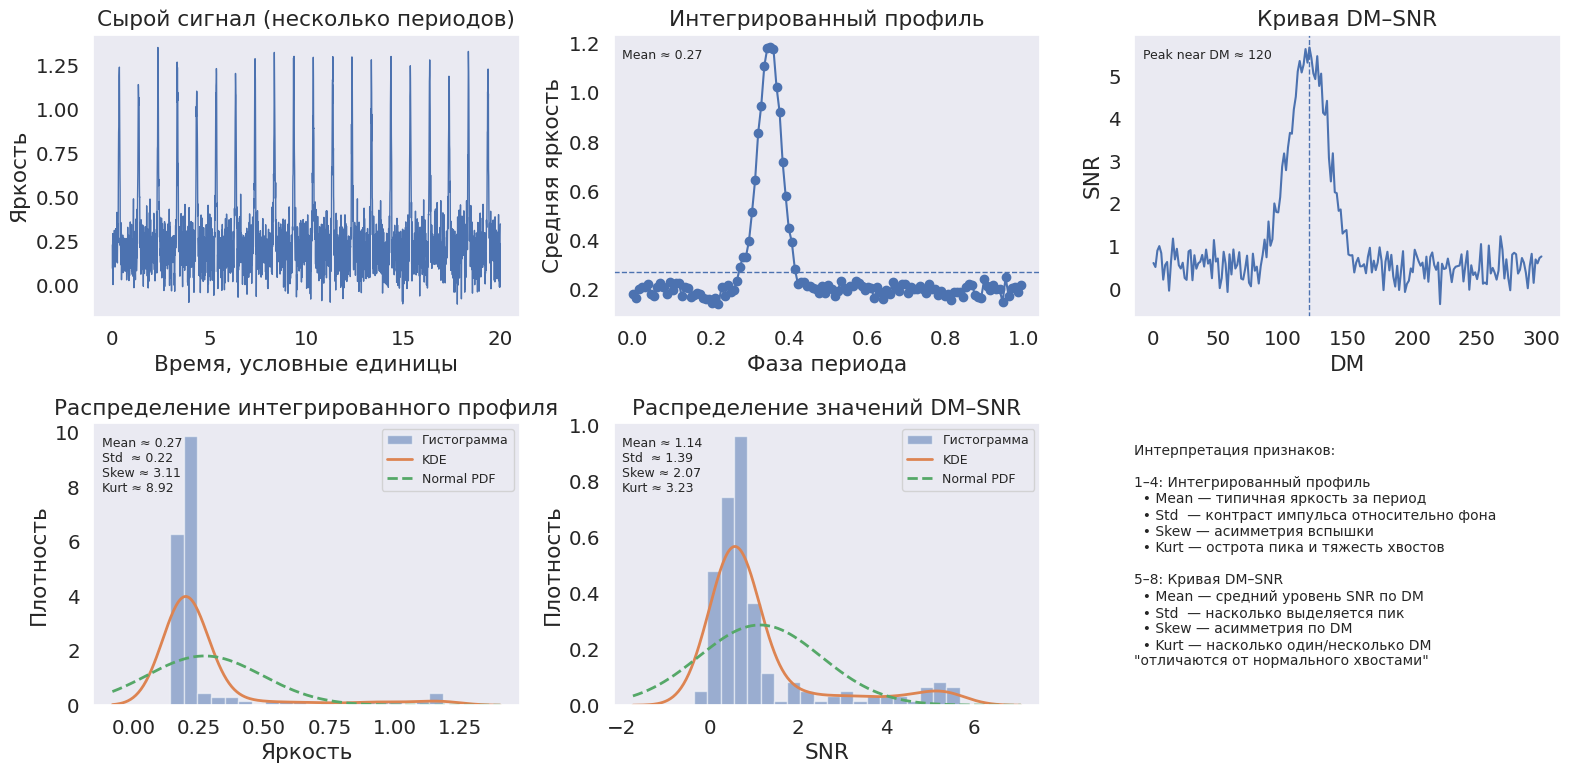
    
    
    

</details>

Укажите, какой датасет выберите:

Predicting Pulsar Star

Скачайте файл и прочитайте его с помощью `pandas`.

In [13]:
path = kagglehub.dataset_download("colearninglounge/predicting-pulsar-starintermediate")
dataset = pd.read_csv(f"{path}/pulsar_data_train.csv")
dataset.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0


Разделите выборку на обучающую и тестовую

In [29]:
dataset.columns = dataset.columns.str.strip()
X = dataset.drop(columns=['target_class'])
y = dataset['target_class']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=0,
)

**1.** Исследуйте данные на предмет количества объектов и признаков, типа признаков, наличия пропусков.

In [31]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 9396 entries, 9333 to 9802
Data columns (total 8 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Mean of the integrated profile                9396 non-null   float64
 1   Standard deviation of the integrated profile  9396 non-null   float64
 2   Excess kurtosis of the integrated profile     8069 non-null   float64
 3   Skewness of the integrated profile            9396 non-null   float64
 4   Mean of the DM-SNR curve                      9396 non-null   float64
 5   Standard deviation of the DM-SNR curve        8490 non-null   float64
 6   Excess kurtosis of the DM-SNR curve           9396 non-null   float64
 7   Skewness of the DM-SNR curve                  8949 non-null   float64
dtypes: float64(8)
memory usage: 660.7 KB


In [32]:
y_train.info()

<class 'pandas.Series'>
Index: 9396 entries, 9333 to 9802
Series name: target_class
Non-Null Count  Dtype  
--------------  -----  
9396 non-null   float64
dtypes: float64(1)
memory usage: 146.8 KB


In [22]:
real_features = [
                 "Mean of the integrated profile", 
                 "Standard deviation of the integrated profile", 
                 "Excess kurtosis of the integrated profile", 
                 "Skewness of the integrated profile",
                 "Mean of the DM-SNR curve",
                 "Standard deviation of the DM-SNR curve",
                 "Excess kurtosis of the DM-SNR curve",
                 "Skewness of the DM-SNR curve",
                ]

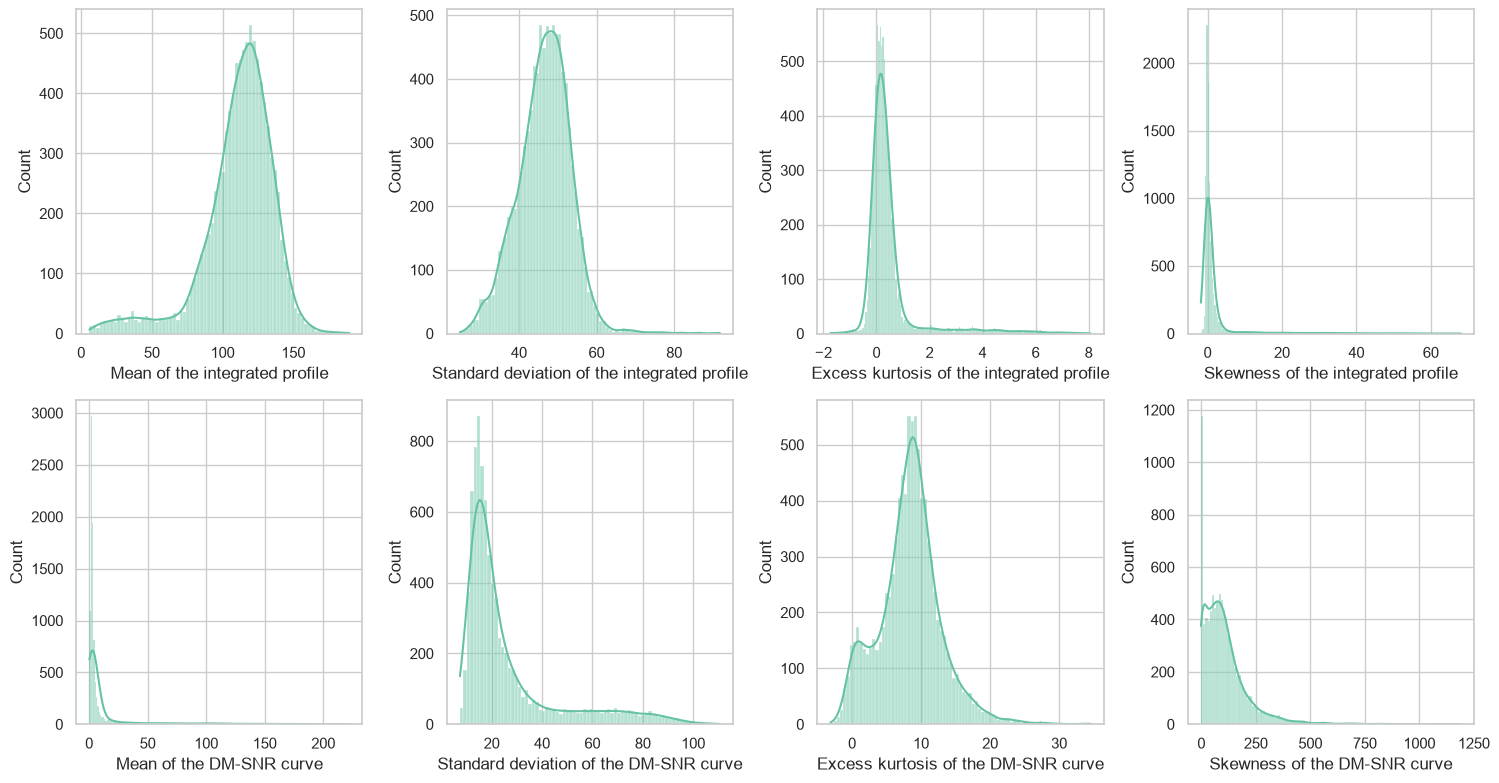

In [34]:
rows = 2
cols = (len(real_features) + 1) // 2

fig, axes = plt.subplots(rows, cols, figsize=(15, 8), squeeze=False)

for feature, ax in zip(real_features, axes.flat):
    sns.histplot(X_train[feature], kde=True, ax=ax)

for ax in axes.flat[len(real_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

Выполните необходимую обработку признаков. Используйте для этого конструкции `ColumnTransformer`, `Pipeline` и подобные.

In [144]:
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
]).set_output(transform="pandas")

X_train_scaled = preprocessor.fit_transform(X_train[real_features])
X_test_scaled = preprocessor.transform(X_test[real_features])

**2.** Обучите две модели логистической регрессии с помощью методов
* простой градиентный спуск;
* стохастический градиентный спуск.

In [71]:
gd_model = MyLogisticRegression(learning_rate=0.01, tol=10e-5)
gd_model.fit(X_train_scaled, y_train)

,learning_rate,0.01
,tol,0.0001
,method,'gd'
,max_iter,10000
,batch_size,64
,fit_intercept,True
,save_history,True
Name,Type,Value
coef_,"ndarray[float64](8,)","[-0.62,-0.03, 0.89,..., 0.34,-0.21,-0.07]"
intercept_,float64,-2.626
n_iter_,int,3025


In [77]:
sgd_model = MyLogisticRegression(method="sgd", batch_size=128, learning_rate=0.01, tol=10e-5)
sgd_model.fit(X_train_scaled, y_train)

,method,'sgd'
,learning_rate,0.01
,tol,0.0001
,batch_size,128
,max_iter,10000
,fit_intercept,True
,save_history,True
Name,Type,Value
coef_,"ndarray[float64](8,)","[-0.57,-0.05, 0.8 ,..., 0.31,-0.18,-0.06]"
intercept_,float64,-2.439
n_iter_,int,2355


Постройте график, на котором нанесите две кривые обучения для рассмотренных методов, каждая из которых отображает зависимость оптимизируемого функционала от номера итерации метода. Нарисуйте также график зависимости этого функционала от времени работы метода. 

*Замечания:*
* Все графики должны быть информативны, с подписанными осями и т.д..
* Для чистоты эксперимента желательно не запускать в момент обучения другие задачи.

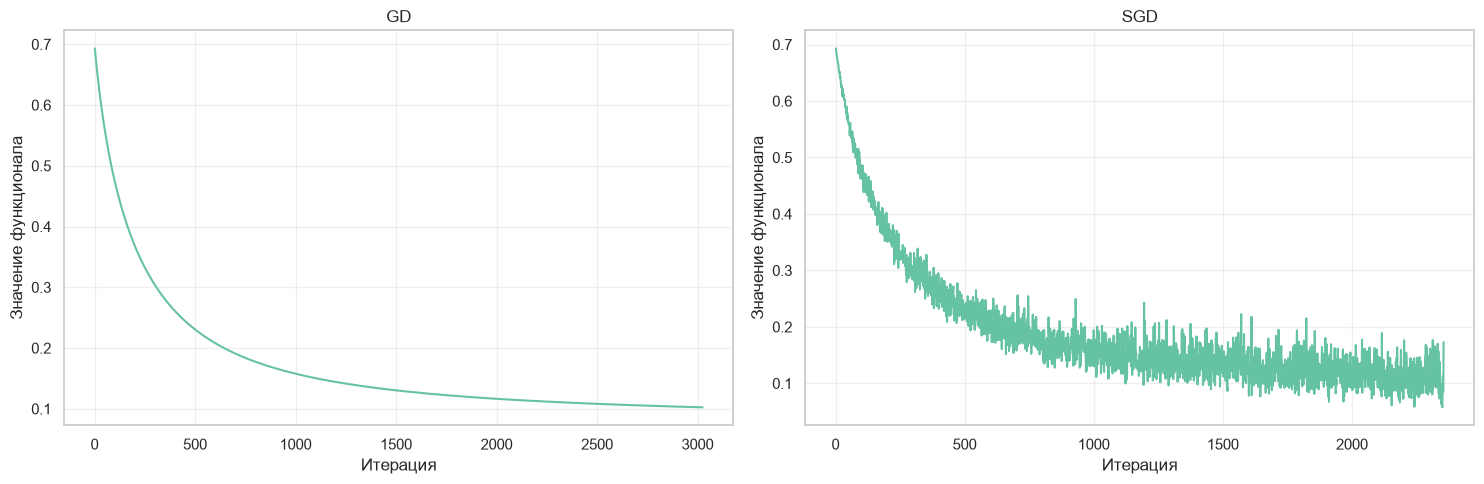

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, model, title in zip(
    axes,
    [gd_model, sgd_model],
    ["GD", "SGD"],
):
    losses = np.asarray(model.history)[:, 1]
    iterations = np.arange(1, len(losses) + 1)

    ax.plot(iterations, losses)
    ax.set_title(title)
    ax.set_xlabel("Итерация")
    ax.set_ylabel("Значение функционала")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

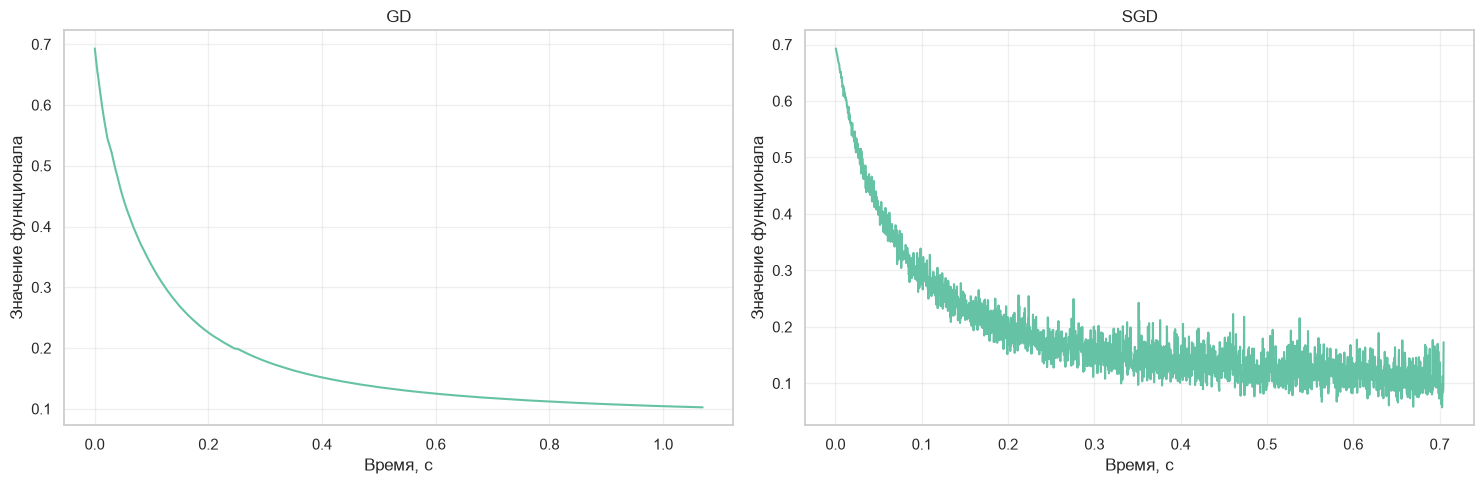

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, model, title in zip(
    axes,
    [gd_model, sgd_model],
    ["GD", "SGD"],
):
    history = np.asarray(model.history)
    times = history[:, 0]
    losses = history[:, 1]

    ax.plot(times, losses)
    ax.set_title(title)
    ax.set_xlabel("Время, с")
    ax.set_ylabel("Значение функционала")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Сделайте выводы. Что будет при обучении на датасете, если  увеличить количество объектов, а число признаков оставить прежним?

На SGD из-за того что оценка функционала идет на случайной подвыборке, она получается довольно шумной.

**3.** Исследуйте влияние размер шага (`learning_rate`) на качество модели для двух режимов обучения (простой и стохастический градиентный спуск). Для каждого размера шага получите качество модели при использовании простого и стохастического градиентного спуска. Сравните качество полученных моделей по метрике `accuracy`.

In [95]:
learning_rate_list = np.logspace(-8, 8, 16)
results = []

for rate in learning_rate_list:
    for method in ["gd", "sgd"]:
        model = MyLogisticRegression(
            method=method,
            batch_size=128,
            learning_rate=rate,
            tol=10e-5,
        )

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)

        results.append({
            "learning_rate": rate,
            "method": method,
            "accuracy": accuracy,
            "history": model.history,
        })

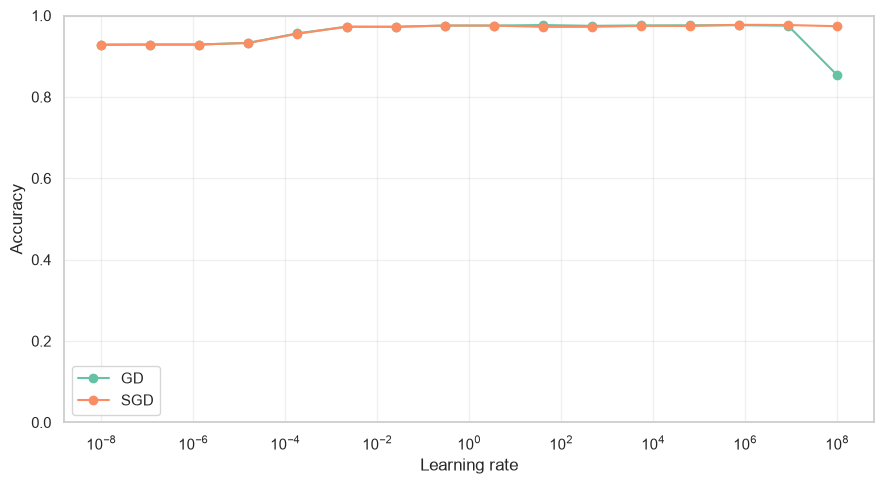

In [96]:
results_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(9, 5))

for method in ["gd", "sgd"]:
    data = (
        results_df[results_df["method"] == method]
        .sort_values("learning_rate")
    )
    ax.plot(
        data["learning_rate"],
        data["accuracy"],
        marker="o",
        label=method.upper(),
    )

ax.set_xscale("log")
ax.set_xlabel("Learning rate")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Сделайте выводы

При маленьком learning_rate судя по всему модель не успевает сойтись, и accuracy не успевает достить оптимума.
При слишком большом learning_rate обучение становится нестабильным..


Постройте кривые обучения для различных `learning_rate`. Не обязательно рассматривать все `learning_rate`, так как их слишком много, и график будет нагроможден. Возьмите около половины из них.

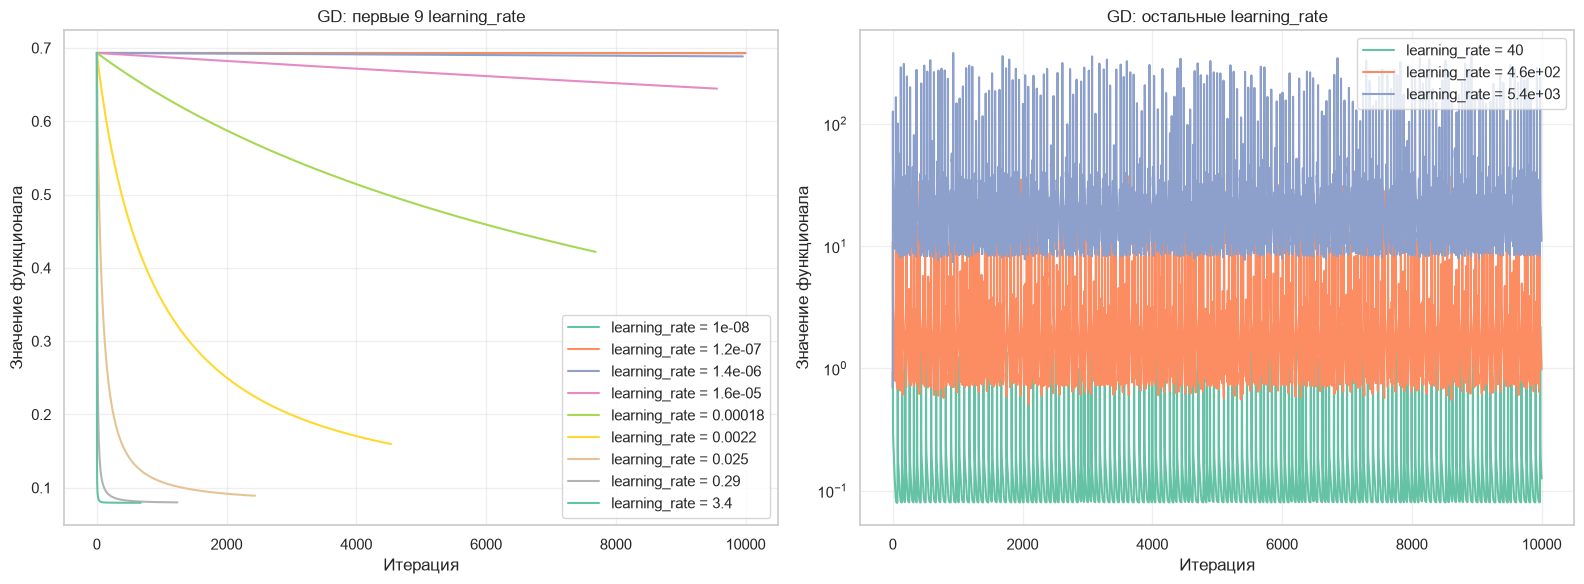

In [111]:
gd_results = (
    results_df[results_df["method"] == "gd"]
    .sort_values("learning_rate")
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title in zip(
    axes,
    [gd_results.iloc[:9], gd_results.iloc[9:12]],
    ["GD: первые 9 learning_rate", "GD: остальные learning_rate"],
):
    for _, row in data.iterrows():
        history = np.asarray(row["history"])
        if history.size == 0:
            continue

        ax.plot(
            np.arange(1, len(history) + 1),
            history[:, 1],
            label=f"learning_rate = {row['learning_rate']:.2g}",
        )

    ax.set_title(title)
    ax.set_xlabel("Итерация")
    ax.set_ylabel("Значение функционала")
    ax.grid(alpha=0.3)
    if ax.lines:
        ax.legend()

axes[1].set_yscale("log")
plt.tight_layout()
plt.show()

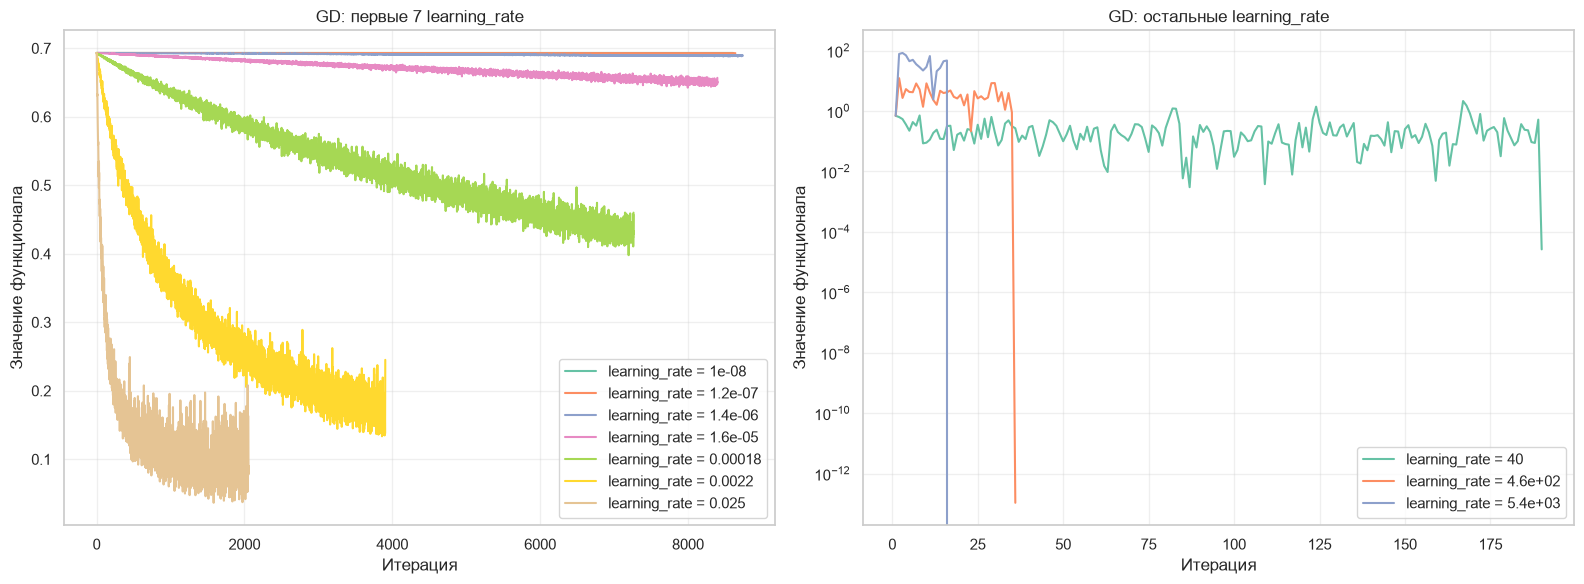

In [119]:
gd_results = (
    results_df[results_df["method"] == "sgd"]
    .sort_values("learning_rate")
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title in zip(
    axes,
    [gd_results.iloc[:7], gd_results.iloc[9:12]],
    ["GD: первые 7 learning_rate", "GD: остальные learning_rate"],
):
    for _, row in data.iterrows():
        history = np.asarray(row["history"])
        if history.size == 0:
            continue

        ax.plot(
            np.arange(1, len(history) + 1),
            history[:, 1],
            label=f"learning_rate = {row['learning_rate']:.2g}",
        )

    ax.set_title(title)
    ax.set_xlabel("Итерация")
    ax.set_ylabel("Значение функционала")
    ax.grid(alpha=0.3)
    if ax.lines:
        ax.legend()

axes[1].set_yscale("log")
plt.tight_layout()
plt.show()

Какой `learning_rate` стоит выбирать в зависимости от способа обучения модели? Чем плохи маленькие и большие `learning_rate`?

Для GD ~= 3.5, для SGD ~= 0.025
При маленьких обучение не успевает сойтись, при больших модель перестает обучаться и сходит с ума.

**4.** Рассмотрите наилучшую модель с предыдущего шага. Визуализируйте значения полученных оценок коэффициентов.

In [149]:
best_model = MyLogisticRegression(
    method="gd",
    batch_size=128,
    learning_rate=3.4,
    tol=10e-5,
)

best_model.fit(X_train_scaled, y_train)

,learning_rate,3.4
,tol,0.0001
,batch_size,128
,method,'gd'
,max_iter,10000
,fit_intercept,True
,save_history,True
Name,Type,Value
coef_,"ndarray[float64](8,)","[-0.9 , 0.59, 2.09,..., 0.8 ,-0.69, 0.07]"
intercept_,float64,-3.71
n_iter_,int,678


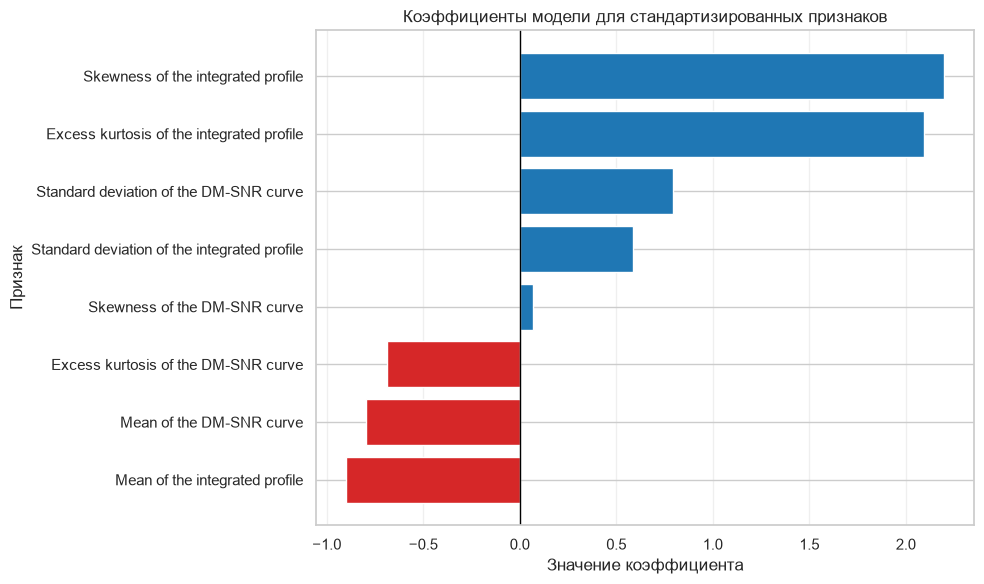

Свободный коэффициент: -3.7102


In [150]:
coefficients = pd.Series(
    np.asarray(best_model.coef_).ravel(),
    index=X_train_scaled.columns,
).sort_values()

colors = np.where(coefficients >= 0, "tab:blue", "tab:red")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coefficients.index, coefficients.values, color=colors)
ax.axvline(0, color="black", linewidth=1)

ax.set_xlabel("Значение коэффициента")
ax.set_ylabel("Признак")
ax.set_title("Коэффициенты модели для стандартизированных признаков")
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"Свободный коэффициент: {best_model.intercept_:.4f}")

Сравните данную модель с бейзлайном, который в качестве предсказания выдает самый частый класс на обучающей выборке.

In [151]:
y_pred = best_model.predict(X_test_scaled)

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train_scaled, y_train)

y_pred_dummy = dummy_model.predict(X_test_scaled)

print(f"Accuracy бейзлайна: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Accuracy модели: {accuracy_score(y_test, y_pred):.4f}")

Accuracy бейзлайна: 0.9080
Accuracy модели: 0.9754


Насколько хорошее получилось качество обученной модели?

ну в целом заметно лучше.

**5.** Исследуйте логит на линейность по некоторым из признаков.

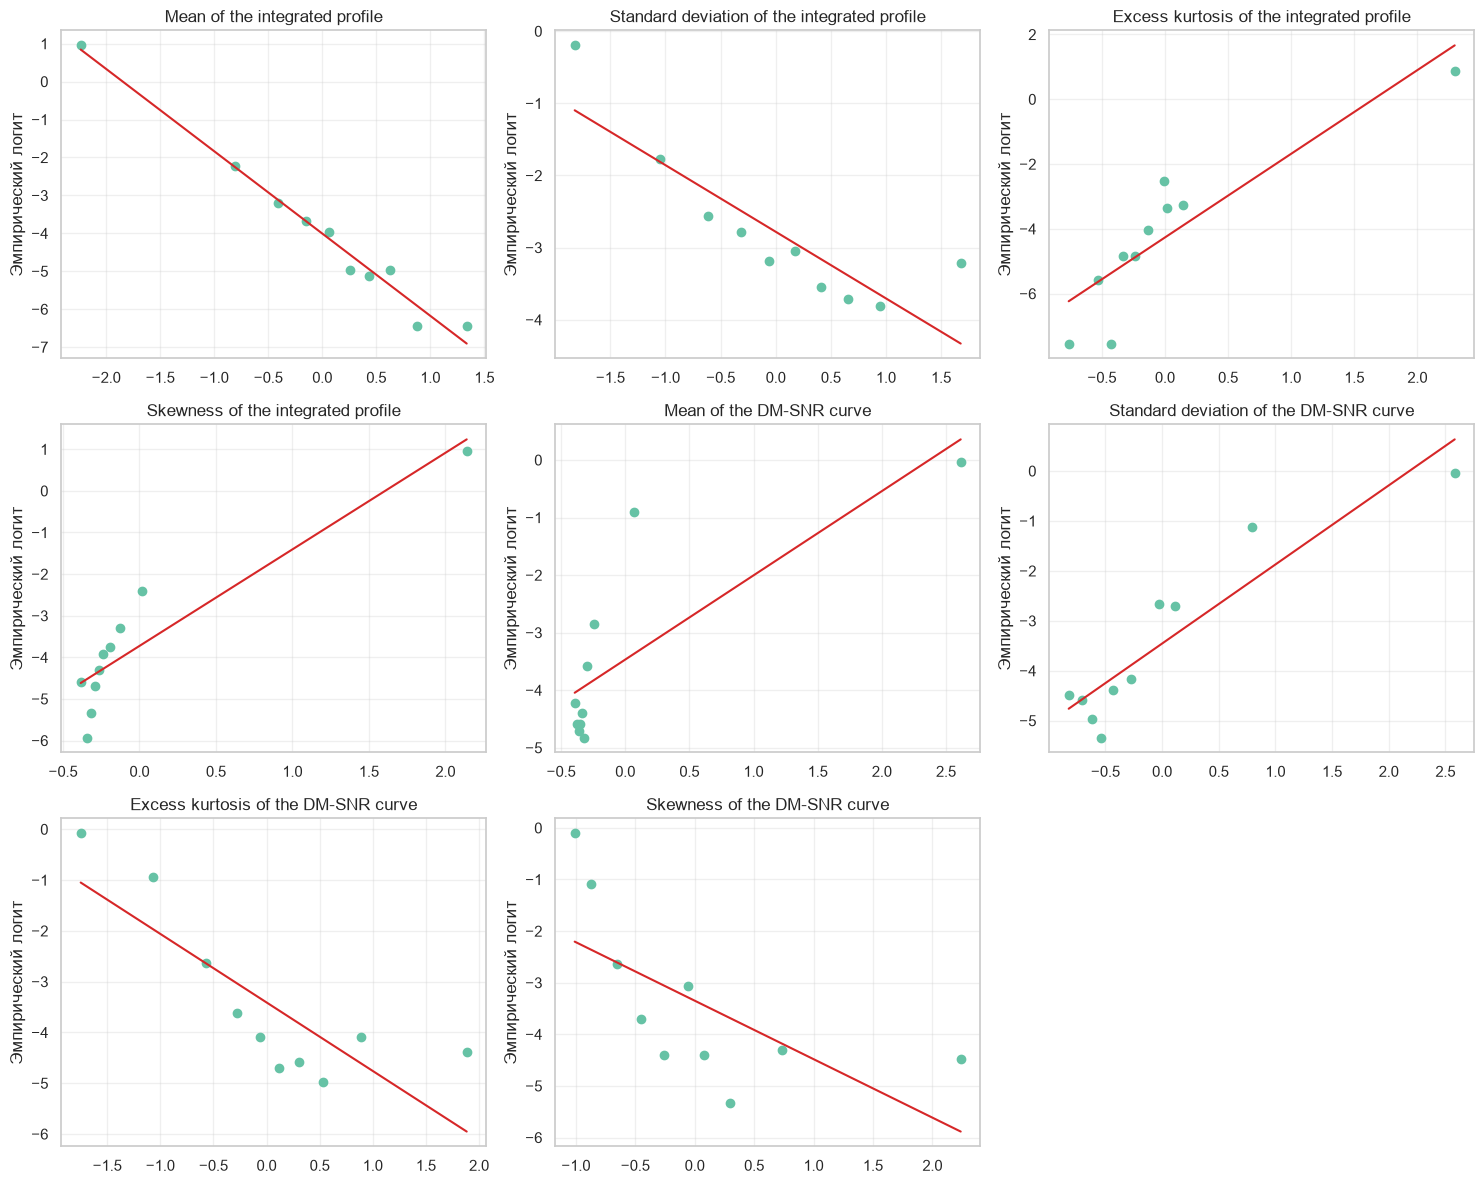

In [131]:
features = X_train_scaled.columns
n_bins = 10
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False,
)

for feature, ax in zip(features, axes.flat):
    data = pd.DataFrame({
        "x": X_train_scaled[feature].to_numpy(),
        "y": np.asarray(y_train).ravel(),
    }).dropna()

    if data["x"].nunique() < 2:
        ax.set_title(feature)
        ax.text(
            0.5, 0.5, "Признак постоянный",
            ha="center", va="center", transform=ax.transAxes,
        )
        continue

    if data["x"].nunique() <= n_bins:
        data["bin"] = data["x"]
    else:
        data["bin"] = pd.qcut(data["x"], q=n_bins, duplicates="drop")

    grouped = (
        data.groupby("bin", observed=True)
        .agg(
            x_mean=("x", "mean"),
            n=("y", "size"),
            n1=("y", "sum"),
        )
        .sort_values("x_mean")
    )

    grouped["n0"] = grouped["n"] - grouped["n1"]
    grouped["logit"] = np.log(
        (grouped["n1"] + 0.5) / (grouped["n0"] + 0.5)
    )

    ax.scatter(
        grouped["x_mean"],
        grouped["logit"],
        label="Эмпирический логит",
    )

    if len(grouped) >= 2:
        slope, intercept = np.polyfit(
            grouped["x_mean"], grouped["logit"], deg=1,
        )
        x_line = np.linspace(
            grouped["x_mean"].min(),
            grouped["x_mean"].max(),
            100,
        )
        ax.plot(
            x_line,
            slope * x_line + intercept,
            color="tab:red",
            label="Линейный тренд",
        )

    ax.set_title(feature)
    ax.set_ylabel("Эмпирический логит")
    ax.grid(alpha=0.3)

for ax in axes.flat[len(features):]:
    ax.remove()

plt.tight_layout()
plt.show()

Есть ли какая-то нелинейность по каким-либо признакам? Если да, попробуйте улучшить модель, рассмотрев преобразования признаков. Сравните полученную модель по качеству с предыдущими.

Достаточно простого решения, тратить много времени на подобный анализ признаков в данном случае не нужно.

Standard deviation of the integrated profile -- похож на x^2
Skewness of the integrated profile -- похже на логарифм
Mean of the DM-SNR curve -- тоже логарифм
Standard deviation of the DM-SNR curve -- попробуем логарифм, хотя в начале что-то непонятное
Excess kurtosis of the DM-SNR curve -- пусть будет x^2
Skewness of the DM-SNR curve -- тоже x^2

In [145]:
def transform_features(X):
    X = X.copy()

    square_features = [
        "Standard deviation of the integrated profile",
        "Excess kurtosis of the DM-SNR curve",
        "Skewness of the DM-SNR curve",
    ]
    log_features = [
        "Mean of the DM-SNR curve",
        "Standard deviation of the DM-SNR curve",
    ]
    skew_feature = "Skewness of the integrated profile"

    for feature in square_features:
        X[f"{feature} (squared)"] = X[feature] ** 2

    for feature in log_features:
        X[f"{feature} (log1p)"] = np.log1p(X[feature])

    X[f"{skew_feature} (signed log1p)"] = (
        np.sign(X[skew_feature])
        * np.log1p(np.abs(X[skew_feature]))
    )

    return X


def transformed_feature_names(transformer, input_features):
    return [
        *input_features,
        "Standard deviation of the integrated profile (squared)",
        "Excess kurtosis of the DM-SNR curve (squared)",
        "Skewness of the DM-SNR curve (squared)",
        "Mean of the DM-SNR curve (log1p)",
        "Standard deviation of the DM-SNR curve (log1p)",
        "Skewness of the integrated profile (signed log1p)",
    ]


preprocessor_2 = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    (
        "transform",
        FunctionTransformer(
            transform_features,
            feature_names_out=transformed_feature_names,
        ),
    ),
    ("scaler", StandardScaler()),
]).set_output(transform="pandas")

X_train_scaled_2 = preprocessor_2.fit_transform(X_train[real_features])
X_test_scaled_2 = preprocessor_2.transform(X_test[real_features])

In [140]:
X_train_scaled_2

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,Standard deviation of the integrated profile (squared),Excess kurtosis of the DM-SNR curve (squared),Skewness of the DM-SNR curve (squared),Mean of the DM-SNR curve (log1p),Standard deviation of the DM-SNR curve (log1p),Skewness of the integrated profile (signed log1p)
9333,0.015758,0.050267,-3.341120e-01,-0.266681,-0.336828,-0.339808,0.056848,-0.262096,-0.022725,-0.174675,-0.258400,-0.380951,-0.191877,-0.343044
12310,-0.458061,-0.682640,-1.767362e-01,-0.115092,-0.376064,-0.851862,1.396314,1.924670,-0.708229,1.352641,1.165978,-0.742643,-1.341749,0.376077
9417,-3.215574,-2.521986,5.957945e+00,6.814560,0.736451,1.745986,-1.403535,-0.976849,-2.086925,-0.932620,-0.357022,1.758158,1.791946,4.010028
6474,0.473354,1.238957,-4.614492e-01,-0.373955,3.104685,2.020397,-2.050088,-1.017924,1.254045,-0.965926,-0.357197,2.784364,1.947018,-0.983837
10695,0.945948,1.896640,-6.052249e-01,-0.378872,-0.323824,-0.246105,-0.027997,-0.330044,2.048158,-0.244605,-0.275552,-0.286375,-0.040469,-1.006652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1217,0.292764,0.433247,-1.059589e-01,-0.281113,-0.374792,-0.812679,1.133679,1.370379,0.366348,0.990422,0.644830,-0.728449,-1.224354,-0.441407
4625,-0.247475,0.199177,-5.128986e-02,-0.213086,-0.315627,-0.405973,-0.172447,-0.363210,0.126037,-0.356313,-0.283331,-0.231298,-0.306598,-0.036279
9337,0.096870,0.996719,-3.015118e-01,-0.321421,-0.339570,-0.386223,0.061213,-0.236680,0.977300,-0.170991,-0.251565,-0.402170,-0.271620,-0.707694
9862,0.941969,1.637181,-3.864554e-01,-0.393097,-0.308786,-0.110111,-0.209252,-0.476583,1.727415,-0.383295,-0.306981,-0.187687,0.159715,-1.070274


In [152]:
best_model_2 = MyLogisticRegression(
    method="gd",
    batch_size=128,
    learning_rate=3.4,
    tol=10e-5,
)

best_model_2.fit(X_train_scaled_2, y_train)
y_pred = best_model_2.predict(X_test_scaled_2)

In [154]:
print(f"Accuracy модели: {accuracy_score(y_test, y_pred):.4f}")

Accuracy модели: 0.9783


получилось 0.9783 против 0.9754 в модели без хитрой модификации данных. Не очень впечатляющий результат.

**6.** Приведите интерпретацию полученных значений оценок коэффициентов относительно рассматриваемых данных в виде "*при изменении признака на 1 у.е. ...*". Мы хотим получить интерпретацию относительно исходных данных, поэтому для ответа на этот вопрос нужно рассматривать признаки *без стандартизации*. Согласуется ли эта интерпретация с вашими личными представлениями о природе данных?

Посмотрите примеры в ноутбуке с занятия. Необходимо привести интерпретацию для нескольких конкретных признаков, общее описание не будет зачтено.


<br/>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Если ранее обучили модель со стандартизацией признаков</summary>

Можно заново обучить модель без стандартизации признаков. Но можно этого и не делать, немного поправив коэффициенты обученной ранее модели (получатся те же коэффициенты после стандартизации). Подумайте, как именно.

</details>

In [156]:
scaler = preprocessor.named_steps["scaler"]

coef_original = np.asarray(best_model.coef_).ravel() / scaler.scale_
intercept_original = (
    best_model.intercept_ - coef_original @ scaler.mean_
)

coefficients = pd.Series(
    coef_original,
    index=scaler.get_feature_names_out(),
    name="Коэффициент без стандартизации",
)

display(coefficients)
print(f"Свободный коэффициент: {intercept_original:.4f}")

Mean of the integrated profile                 -0.035211
Standard deviation of the integrated profile    0.085682
Excess kurtosis of the integrated profile       2.137754
Skewness of the integrated profile              0.356255
Mean of the DM-SNR curve                       -0.026953
Standard deviation of the DM-SNR curve          0.042724
Excess kurtosis of the DM-SNR curve            -0.151572
Skewness of the DM-SNR curve                    0.000655
Name: Коэффициент без стандартизации, dtype: float64

Свободный коэффициент: -5.0108


In [158]:
for feature, coef in coefficients.items():
    print(
        f'При увеличении "{feature}" на 1 '
        f'логит вероятности изменится на {coef:+.4f} '
        f'при фиксированных остальных признаках модели.'
    )

При увеличении "Mean of the integrated profile" на 1 логит вероятности изменится на -0.0352 при фиксированных остальных признаках модели.
При увеличении "Standard deviation of the integrated profile" на 1 логит вероятности изменится на +0.0857 при фиксированных остальных признаках модели.
При увеличении "Excess kurtosis of the integrated profile" на 1 логит вероятности изменится на +2.1378 при фиксированных остальных признаках модели.
При увеличении "Skewness of the integrated profile" на 1 логит вероятности изменится на +0.3563 при фиксированных остальных признаках модели.
При увеличении "Mean of the DM-SNR curve" на 1 логит вероятности изменится на -0.0270 при фиксированных остальных признаках модели.
При увеличении "Standard deviation of the DM-SNR curve" на 1 логит вероятности изменится на +0.0427 при фиксированных остальных признаках модели.
При увеличении "Excess kurtosis of the DM-SNR curve" на 1 логит вероятности изменится на -0.1516 при фиксированных остальных признаках модели

**7.** Какие больше всего влияют на изменение вероятности класса 1? Согласуются ли эти выводы с вашими личными представлениями о природе данных?

Ответ на этот вопрос не следует из предыдущего, поскольку там мы рассматривали коэффициенты как величины, имеющие различные единицы измерения. Чтобы сравнить коэффициенты, нам потребуется стандартизировать признаки, тем самым обезразмерить их и соответствующие коэффициенты. 


<br/>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Если ранее обучили модель без стандартизации признаков</summary>

Стандартизацию можно сделать с помощью <code>StandardScaler()</code> и обучить модель логистической регрессии заново. Но можно этого и не делать, немного поправив коэффициенты обученной ранее модели (получатся те же коэффициенты после стандартизации). Подумайте, как именно.

</details>

Больше всего влияют Skewness of the integrated profile и Excess kurtosis of the integrated profile (следует из слолбчатой диаграммы выше)

**8. Вывод:**

1. Для логрегрессии крайне желательно нормировать данные.
2. Результат 97%, достаточно неплохо.
3. Я терпеть не могу jupyter.

*Надеемся, что ты все успел, и тебе понравилось! Ждем тебя на следующей лекции!*

<div style="box-sizing:border-box;max-width:100%;margin-top:42px;padding:18px 0 4px;border-top:1px solid rgba(127, 127, 127, 0.28);color:inherit;font-size:0.9em;line-height:1.5;"><img src="https://thetahat.ru/images/logo_thetahat.png" alt="ThetaHat" style="display:block!important;width:34px!important;max-width:34px!important;height:auto!important;margin:0 0 9px 0!important;padding:0!important;">© 2026 команда <a href="https://thetahat.ru/" style="color:inherit;font-weight:750;text-decoration:underline;text-decoration-color:#F13A3F;text-underline-offset:3px;">ThetaHat</a> для курса ML-1 ШАД</div>